# Importing Libraries and loading the data

In [2]:
import pandas as pd

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the Data 
df = pd.read_csv("telecom_customer_churn.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5141 entries, 0 to 5140
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        5141 non-null   object 
 1   Gender                             5141 non-null   object 
 2   Age                                5141 non-null   int64  
 3   Married                            5141 non-null   object 
 4   Number of Dependents               5141 non-null   int64  
 5   City                               5141 non-null   object 
 6   Zip Code                           5140 non-null   float64
 7   Latitude                           5140 non-null   float64
 8   Longitude                          5140 non-null   float64
 9   Number of Referrals                5140 non-null   float64
 10  Tenure in Months                   5140 non-null   float64
 11  Offer                              2301 non-null   objec

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,5141.000000,5141.000000,5140.000000,5140.000000,5140.000000,5140.000000,5140.000000,4650.000000,4029.000000,5140.000000,5140.000000,5140.000000,5140.000000,5140.000000,5140.000000
mean,46.566038,0.468586,93499.687354,36.221167,-119.772809,1.958560,32.368677,25.573559,26.204269,63.853074,2286.079434,1.818354,6.803502,752.578424,3043.643006
std,16.769221,0.963555,1851.741638,2.474546,2.161757,2.992895,24.524751,14.277684,19.640405,31.248867,2270.543962,7.569116,24.969261,846.459008,2870.075219
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.400000
25%,32.000000,0.000000,92109.000000,33.998471,-121.823565,0.000000,9.000000,13.172500,12.000000,30.537500,399.400000,0.000000,0.000000,70.850000,603.135000
50%,46.000000,0.000000,93528.000000,36.276880,-119.667544,0.000000,29.000000,25.770000,21.000000,70.200000,1399.575000,0.000000,0.000000,407.905000,2116.070000
75%,60.000000,0.000000,95330.750000,38.167495,-117.982564,3.000000,55.000000,38.135000,30.000000,89.900000,3802.375000,0.000000,0.000000,1195.422500,4832.660000
max,80.000000,9.000000,96148.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.600000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [3]:
#Drop Unnecessary Columns

df.drop(['Customer ID', 'Zip Code', 'Latitude', 'Longitude'], axis=1, inplace=True, errors='ignore')

#  Handling Missing Values

In [5]:
df['Offer'] = df['Offer'].fillna('No Offer')

In [6]:
cols = ['Internet Type','Online Security','Online Backup',
        'Device Protection Plan','Premium Tech Support',
        'Streaming TV','Streaming Movies','Streaming Music',
        'Unlimited Data']

for col in cols:
    df[col] = df[col].fillna('No Internet')

In [7]:
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)

df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)

df['Number of Referrals'] = df['Number of Referrals'].fillna(0)

df['Tenure in Months'] = df['Tenure in Months'].fillna(0)

In [8]:
df['Churn Category'] = df['Churn Category'].fillna('No Churn')
df['Churn Reason'] = df['Churn Reason'].fillna('Not Applicable')

#  Converting Target Variable to Binary Format

In [10]:
df['Customer Status'].value_counts()

Customer Status
Stayed     3433
Churned    1384
Joined      323
Name: count, dtype: int64

In [11]:
df['Churn'] = df['Customer Status'].apply(lambda x: 1 if x == 'Churned' else 0)

In [12]:
df.head()

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,...,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Churn
0,Female,37,Yes,0,Frazier Park,2.0,9.0,No Offer,Yes,42.39,...,65.6,593.30,0.00,0.0,381.51,974.81,Stayed,No Churn,Not Applicable,0
1,Male,46,No,0,Glendale,0.0,9.0,No Offer,Yes,10.69,...,-4.0,542.40,38.33,10.0,96.21,610.28,Stayed,No Churn,Not Applicable,0
2,Male,50,No,0,Costa Mesa,0.0,4.0,Offer E,Yes,33.65,...,73.9,280.85,0.00,0.0,134.60,415.45,Churned,Competitor,Competitor had better devices,1
3,Male,78,Yes,0,Martinez,1.0,13.0,Offer D,Yes,27.82,...,98.0,1237.85,0.00,0.0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,1
4,Female,75,Yes,0,Camarillo,3.0,3.0,No Offer,Yes,7.38,...,83.9,267.40,0.00,0.0,22.14,289.54,Churned,Dissatisfaction,Network reliability,1


#  Exploratory Data Analysis

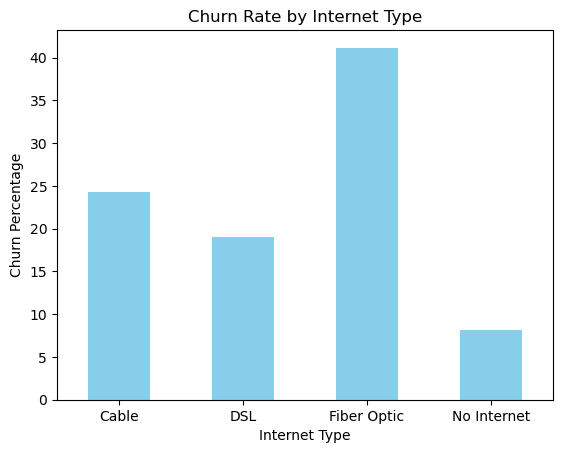

In [14]:
#Insight:
# Churn rate is highest for Fiber Optic users, while DSL and Cable show lower churn,
# suggesting Fiber services may need improvement in pricing or quality.
churn_rate = pd.crosstab(
    df['Internet Type'], 
    df['Customer Status'], 
    normalize='index'
) * 100
churn_only = churn_rate['Churned']
churn_only.plot(
     kind='bar',
     color='skyblue',
)

plt.title("Churn Rate by Internet Type")
plt.ylabel("Churn Percentage")
plt.xlabel("Internet Type")
plt.xticks(rotation=0)
plt.show()

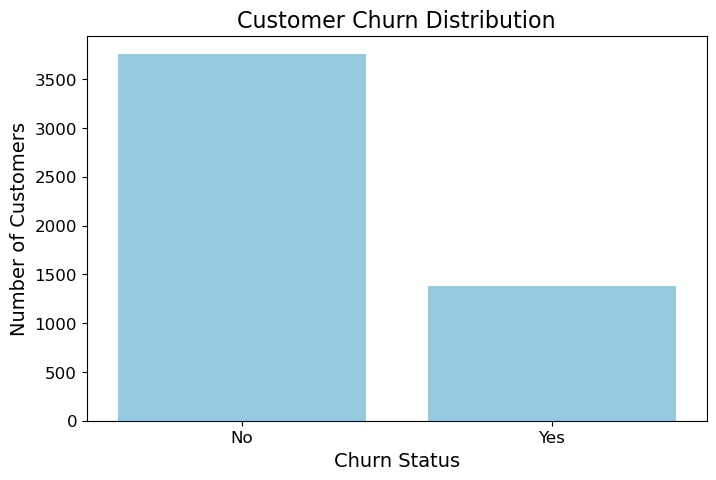

In [15]:
# Insight:
# Although most customers remain with the company, a significant number have churned,
# indicating underlying issues that may lead to customer dissatisfaction.
# This emphasizes the importance of identifying and targeting at-risk customers.

plt.figure(figsize=(8,5))

sns. countplot(
    data=df,
    x='Churn',
    color='skyblue'
)

plt.title("Customer Churn Distribution", fontsize=16)
plt.xlabel("Churn Status", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)

plt.xticks([0,1], ['No', 'Yes'])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

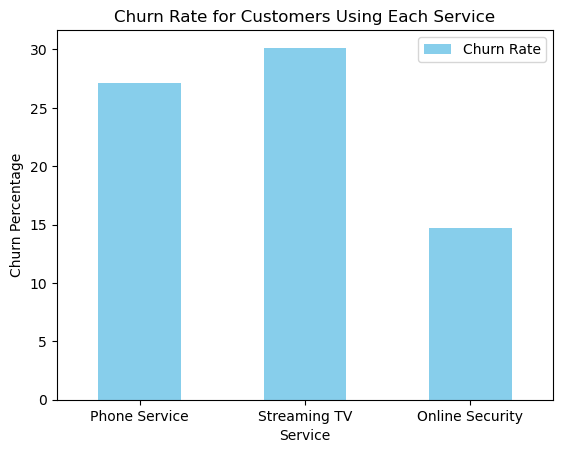

In [16]:
# Churn is highest among Streaming TV users and lowest among customers with Online Security,
# suggesting that security services help retain customers more effectively.

services = ['Phone Service', 'Streaming TV', 'Online Security']
churn_data = {}
for service in services:
    churn_rate = pd.crosstab(
        df[service],
        df['Customer Status'],
        normalize='index'
    ) * 100
    
    churn_data[service] = churn_rate.loc['Yes', 'Churned']

# Convert to dataframe
churn_df = pd.DataFrame.from_dict(churn_data, orient='index', columns=['Churn Rate'])
import matplotlib.pyplot as plt

churn_df.plot(kind='bar', color='skyblue')

plt.title("Churn Rate for Customers Using Each Service")
plt.ylabel("Churn Percentage")
plt.xlabel("Service")
plt.xticks(rotation=0)

plt.show()

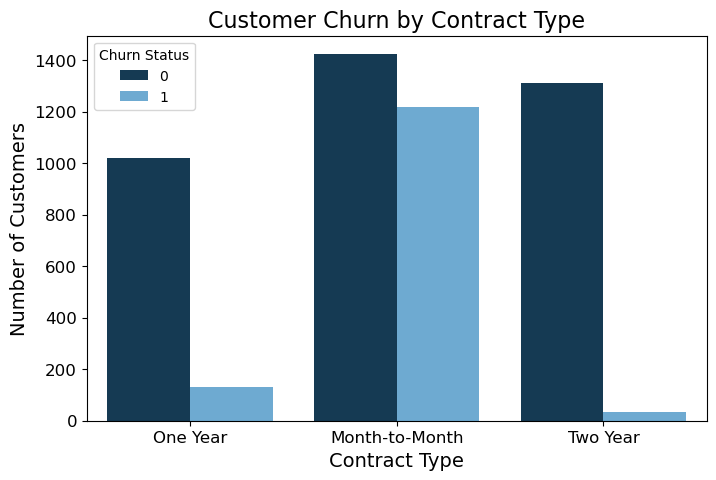

In [17]:
# Insight:
# The analysis shows that customers on flexible month-to-month contracts are more likely to churn,
# while those on long-term contracts (one-year and two-year) demonstrate higher retention.
# This suggests that longer commitment plans improve customer loyalty and reduce churn risk.

plt.figure(figsize=(8,5))

sns. countplot(
    data=df,
    x='Contract',
    hue='Churn',
    palette = ['#0B3C5D', '#5DADE2'] 
)

plt.title("Customer Churn by Contract Type", fontsize=16)
plt.xlabel("Contract Type", fontsize=14)
plt.ylabel("Number of Customers", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(title="Churn Status")

plt.show()

In [18]:
# Dropping  Leakage Columns

df.drop(['Customer Status','Churn Category','Churn Reason'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5141 entries, 0 to 5140
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             5141 non-null   object 
 1   Age                                5141 non-null   int64  
 2   Married                            5141 non-null   object 
 3   Number of Dependents               5141 non-null   int64  
 4   City                               5141 non-null   object 
 5   Number of Referrals                5141 non-null   float64
 6   Tenure in Months                   5141 non-null   float64
 7   Offer                              5141 non-null   object 
 8   Phone Service                      5140 non-null   object 
 9   Avg Monthly Long Distance Charges  5141 non-null   float64
 10  Multiple Lines                     4650 non-null   object 
 11  Internet Service                   5140 non-null   objec

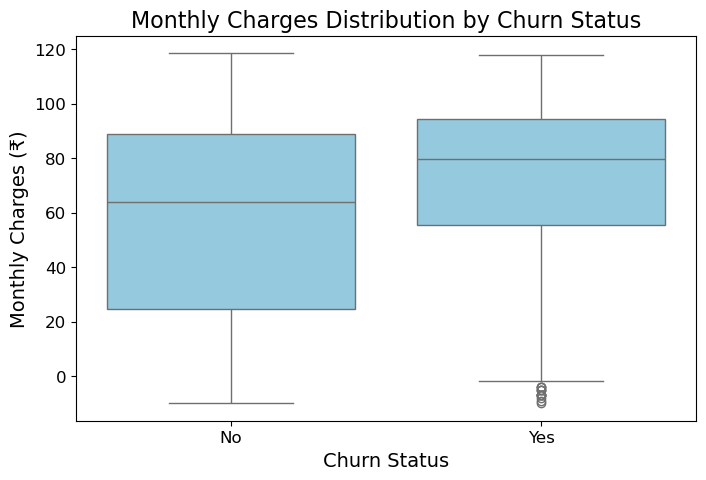

In [19]:
# Insight:
# Customers with higher monthly charges exhibit a greater tendency to churn,
# as indicated by the higher median and spread in the churned group.
# This suggests that expensive plans may lead to dissatisfaction,
# making pricing a critical factor in customer retention strategies.

plt.figure(figsize=(8,5))

sns. boxplot(
    data=df,
    x='Churn',
    y='Monthly Charge', 
    color='skyblue'
)

plt.title("Monthly Charges Distribution by Churn Status", fontsize=16)
plt.xlabel("Churn Status", fontsize=14)
plt.ylabel("Monthly Charges (₹)", fontsize=14)

plt.xticks([0,1], ['No', 'Yes'], fontsize=12)
plt.yticks(fontsize=12)

plt.show()

In [20]:
df = pd.get_dummies(df, drop_first=True)

In [21]:
df.head()

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,...,Streaming Movies_Yes,Streaming Music_No Internet,Streaming Music_Yes,Unlimited Data_No Internet,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
0,37,0,2.0,9.0,42.39,16.0,65.6,593.30,0.00,0.0,...,False,False,False,False,True,True,False,True,True,False
1,46,0,0.0,9.0,10.69,10.0,-4.0,542.40,38.33,10.0,...,True,False,True,False,False,False,False,False,True,False
2,50,0,0.0,4.0,33.65,30.0,73.9,280.85,0.00,0.0,...,False,False,False,False,True,False,False,True,False,False
3,78,0,1.0,13.0,27.82,4.0,98.0,1237.85,0.00,0.0,...,True,False,False,False,True,False,False,True,False,False
4,75,0,3.0,3.0,7.38,11.0,83.9,267.40,0.00,0.0,...,False,False,False,False,True,False,False,True,True,False


In [22]:
# Dropping  Leakage Columns
X = df.drop('Churn', axis=1)
y = df['Churn']

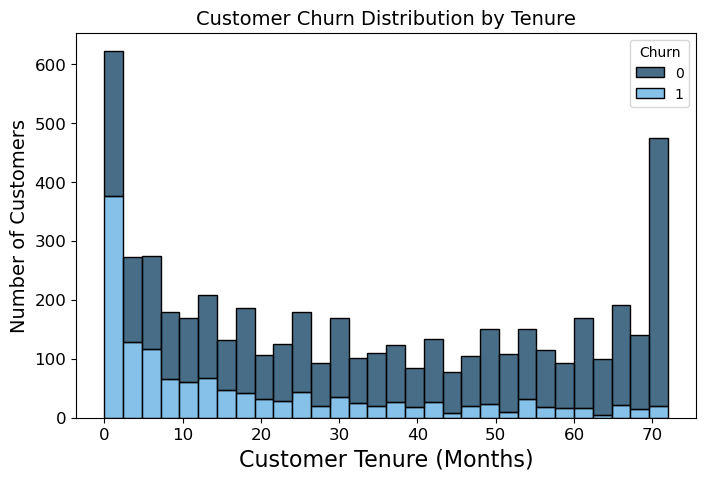

In [23]:
# Insight:
# The graph indicates a strong negative relationship between tenure and churn,
# where customers with shorter tenure are significantly more likely to churn.
# This suggests that early customer engagement and onboarding strategies
# are critical to improving retention.

plt.figure(figsize=(8,5))
sns. histplot(
    data=df,
    x='Tenure in Months',
    hue='Churn',
    bins=30,
    multiple='stack',
    palette = ['#0B3C5D', '#5DADE2']
)

# Labels & styling

plt.xlabel("Customer Tenure (Months)",fontsize=16)
plt.ylabel("Number of Customers",fontsize=14)
plt.title("Customer Churn Distribution by Tenure",fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

#  Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Building

In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

#  Model Evaluation

In [29]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8250728862973761


In [30]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[697  54]
 [126 152]]


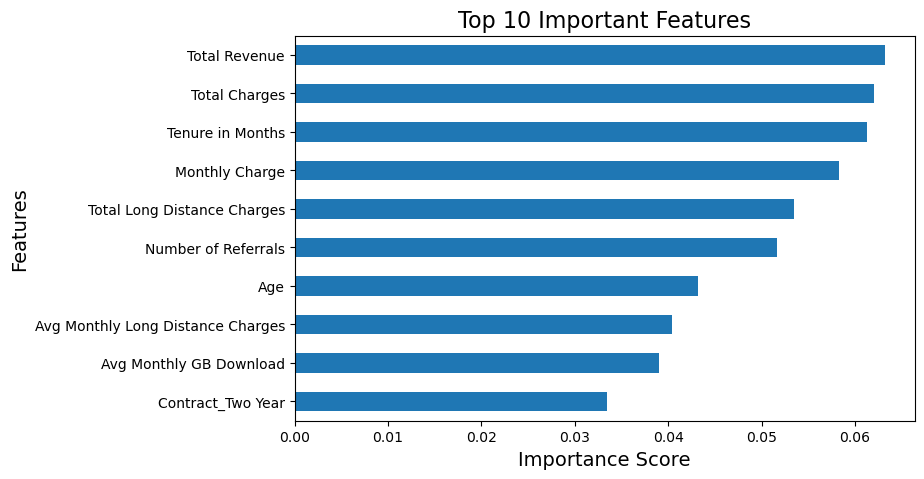

In [31]:
# Insight:
# The visualization highlights the most influential features driving customer churn.
# Top-ranked features play a significant role in prediction,
# indicating key areas to focus on for improving customer retention.

importance = pd.Series(model.feature_importances_, index=X.columns)

# Sort and take top 10
top_features = importance.sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind='barh')

plt.title("Top 10 Important Features", fontsize=16)
plt.xlabel("Importance Score", fontsize=14)
plt.ylabel("Features", fontsize=14)

plt.show()

# Save Model

In [63]:
import joblib
joblib.dump(model, "churn_model.pkl")

['churn_model.pkl']